In [1]:
import os
os.chdir('/workspace/c886c986-ee90-4836-a6f5-c2b2c5692c81')
print(os.listdir('.'))


['description.npy', 'F2_t.npy', '.config', 'a.npy', 'F5m_t.npy', 'F9.npy', 'memory', 'coeffs_F9_a.npy', 'F5p_t.npy', 'F5m.npy', 'F4.npy', 'F1.npy', 'F4_t.npy', 'F10.npy', 'F6.npy', ' v6 — Binding Context Document.pdf', 'rho0.npy', 'F7_t.npy', 'F2.npy', 'F1_t.npy', 'F9_t.npy', '.kernel_llm_logs_1.txt', 'F10_t.npy', 'F11_t.npy', 'F12_t.npy', 'c.npy', 'F6_t.npy', 'F12.npy', 'F5p.npy', 'F7.npy', 'coeffs_F10_a.npy', 'F11.npy', '.prompts']


In [2]:
import numpy as np

# These look like the Sk arrays. Let's check
F1 = np.load('F1.npy')
F1t = np.load('F1_t.npy')
print('F1.shape:', F1.shape, 'dtype:', F1.dtype)
print('F1_t.shape:', F1t.shape)
desc = np.load('description.npy', allow_pickle=True)
print('description:', desc)


F1.shape: (200, 8) dtype: complex128
F1_t.shape: (200,)
description: F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [3]:
# Good. F1..F12 are arrays of complex S_k values per peak (200 peaks x 8 k values).
# Confirm structure for each class
classes = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
for c in classes:
 arr = np.load(f'{c}.npy')
 t = np.load(f'{c}_t.npy')
 print(f'{c}: S shape {arr.shape}, t shape {t.shape}, dtype {arr.dtype}')


F1: S shape (200, 8), t shape (200,), dtype complex128
F2: S shape (200, 8), t shape (200,), dtype complex128
F4: S shape (200, 8), t shape (200,), dtype complex128
F5p: S shape (200, 8), t shape (200,), dtype complex128
F5m: S shape (200, 8), t shape (200,), dtype complex128
F6: S shape (200, 8), t shape (200,), dtype complex128
F7: S shape (200, 8), t shape (200,), dtype complex128
F9: S shape (200, 8), t shape (200,), dtype complex128
F10: S shape (200, 8), t shape (200,), dtype complex128
F11: S shape (200, 8), t shape (200,), dtype complex128
F12: S shape (200, 8), t shape (200,), dtype complex128


In [4]:
# Great. Empirical matrix M_jk = E[Re(S_j conj(S_k))]
empirical_M = {}
for c in classes:
 S = np.load(f'{c}.npy') # (200, 8) complex
 # outer product per peak: S[:,j] * conj(S[:,k])
 M = np.real(np.einsum('pj,pk->jk', S, np.conj(S))) / S.shape[0]
 empirical_M[c] = M
 print(c, 'M trace:', np.trace(M))


F1 M trace: 114.04394263994386
F2 M trace: 124.22503510160097
F4 M trace: 39.14695007358752
F5p M trace: 40.3241161993106
F5m M trace: 38.17938598410145
F6 M trace: 301.7464252287516
F7 M trace: 67.58054269865957
F9 M trace: 71.05581070470294
F10 M trace: 129.72698534651605
F11 M trace: 124.74237735641549
F12 M trace: 498.67022975311687


In [5]:
# Now we need to compute the theoretical C_jk = Re[ sum_{n,m<=N; w(n)=j, w(m)=k} a_n conj(a_m)/(n m) ]
# This factorizes! Let T_j = sum_{n<=N; w(n)=j} a_n / n (complex, possibly).
# Then C_jk = Re[ T_j * conj(T_k) ]
# Wait, actually: sum_{n,m} a_n conj(a_m) / (n m) with constraints w(n)=j, w(m)=k
# = (sum_{n: w(n)=j} a_n/n) * (sum_{m: w(m)=k} conj(a_m)/m)
# = T_j * conj(T_k) where T_j = sum_{n: w(n)=j, n<=N} a_n/n
# So C_jk = Re[T_j conj(T_k)]

# Need to load Dirichlet coefficients a_n for each class up to 10^6.
# Need omega(n) (number of distinct prime factors) for n up to 10^6, capped at 7+ ?
# Actually the stratification: ω(n) = # distinct prime factors. k=0..7 means k=0 (n=1), k=1, ..., k=7.
# What about n with omega(n) >= 8? Likely either binned to k=7 or excluded. Let's check.

# 510510 = 2*3*5*7*11*13*17 has omega=7. Smallest with omega=8 is 9699690. So none < 10^6.
# So k = 0..7 covers exactly omega = 0..7. Good.
N = 10**6
print('Computing omega(n) sieve...')
omega = np.zeros(N+1, dtype=np.int8)
# sieve of distinct prime factors
for p in range(2, N+1):
 if omega[p] == 0: # p is prime if omega is still 0 AND we haven't been visited
 # but actually we need a proper prime sieve
 pass
# Use a different approach: compute distinct prime factor count
omega = np.zeros(N+1, dtype=np.int8)
is_prime = np.ones(N+1, dtype=bool)
is_prime[:2] = False
for p in range(2, N+1):
 if is_prime[p]:
 # mark multiples
 idx = np.arange(p, N+1, p)
 omega[idx] += 1
 is_prime[p*p::p] = False if p*p <= N else False
print('done; omega max:', omega.max(), 'omega(1)=', omega[1])
print('counts per k:', np.bincount(omega))


Computing omega(n) sieve...


done; omega max: 7 omega(1)= 0
counts per k: [ 2 78734 288726 379720 208034 42492 2285 8]


In [6]:
# omega[0] entry counted as 0. omega for indices 0 and 1 should be 0; sum is 2 (but n=0 we ignore).
# Actually the sieve marks p, then is_prime[p*p::p] for composites. But we use omega[p] += 1 for primes
# AND for composites. Let me verify:
# For p prime, we do omega[idx] += 1 where idx = multiples of p. So both p and 2p, 3p etc get +1.
# Then is_prime[p*p::p] = False marks composites. But we still iterate p forward; so for q=4 prime check fails.
# This gives correct omega. Good.

# Now we need a_n for each function class. Let me determine each:
# F1: zeta -> a_n = 1
# F2: Davenport-Heilbronn? But mod-5 coefficients. Actually F2 is the DH function with κ. Need spec.

# Let me check the binding context document briefly to confirm class definitions


In [7]:
# Now I need a_n for each function class. Let me prepare:
# F1: ζ -> a_n=1
# F2: L(s,χ_4 mod 5) -- chi mod 5 (Dirichlet character mod 5)
# F4: L_DH (Davenport-Heilbronn)
# F5p, F5m: L_DH(ε), ε=±0.05
# F6: Liouville λ(n)=(-1)^Ω(n)
# F7: Möbius μ(n)
# F9: Ramanujan Δ (file: coeffs_F9_a.npy)
# F10: weight 2 newform (file: coeffs_F10_a.npy)
# F11: Sym² L(s,Δ) - need to construct
# F12: file coeffs_F12_N1e6.npz... but actually here a.npy and c.npy

# Let me check what files we have
import os
for f in sorted(os.listdir('.')):
 if f.endswith('.npy') or f.endswith('.npz'):
 print(f, os.path.getsize(f))


F1.npy 25728
F10.npy 25728
F10_t.npy 1728
F11.npy 25728
F11_t.npy 1728
F12.npy 25728
F12_t.npy 1728
F1_t.npy 1728
F2.npy 25728
F2_t.npy 1728
F4.npy 25728
F4_t.npy 1728
F5m.npy 25728
F5m_t.npy 1728
F5p.npy 25728
F5p_t.npy 1728
F6.npy 25728
F6_t.npy 1728
F7.npy 25728
F7_t.npy 1728
F9.npy 25728
F9_t.npy 1728
a.npy 16000128
c.npy 144
coeffs_F10_a.npy 8000128
coeffs_F9_a.npy 15081326
description.npy 1464
rho0.npy 144


In [8]:
# a.npy and c.npy and rho0.npy are F12 components
# a.npy: 16MB suggests complex128 with 10^6 -> exactly 16MB ✓
F12_a = np.load('a.npy')
print('F12 a:', F12_a.shape, F12_a.dtype)
F12_c = np.load('c.npy')
print('F12 c:', F12_c)
F12_rho0 = np.load('rho0.npy')
print('F12 rho0:', F12_rho0)


F12 a: (1000000,) complex128
F12 c: (-0.16567330026345564+1.9009252335917202j)
F12 rho0: (0.7+7j)


In [9]:
F9_a = np.load('coeffs_F9_a.npy', allow_pickle=True)
F10_a = np.load('coeffs_F10_a.npy', allow_pickle=True)
print('F9 a:', F9_a.shape, F9_a.dtype, F9_a[:5])
print('F10 a:', F10_a.shape, F10_a.dtype, F10_a[:5])


F9 a: (1000000,) object [1 -24 252 -1472 4830]
F10 a: (1000000,) int64 [ 1 -2 -1 2 1]


In [10]:
# Note these are 0-indexed: a[0]=a_1, etc.
# Let's set up generation for missing classes.

N = 10**6
n_arr = np.arange(1, N+1) # n=1..N
# omega for n=1..N - use omega array indexed 1..N
omega_n = omega[1:N+1].astype(np.int64)
print('omega range:', omega_n.min(), omega_n.max())

# Quick check: omega at n=1 should be 0
print('omega(1)=', omega_n[0], 'omega(2)=', omega_n[1], 'omega(6)=', omega_n[5], 'omega(30)=', omega_n[29])


omega range: 0 7
omega(1)= 0 omega(2)= 1 omega(6)= 2 omega(30)= 3


In [11]:
# F1: a_n = 1
a_F1 = np.ones(N, dtype=np.complex128)

# F2: L(s, χ mod 5). Which character? "χ_4 mod 5" - the unique odd character mod 5 is order 4.
# Characters mod 5: there are 4 chars. The non-principal real one (Legendre) is order 2.
# χ_4 mod 5 means an order-4 character (complex). χ(g)=i where g is primitive root mod 5 (g=2).
# χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(5)=0, then periodic.
# Verify: χ(2*3)=χ(6)=χ(1)=1; χ(2)*χ(3)=i*(-i)=1 ✓
# χ(2*2)=χ(4)=-1; χ(2)*χ(2)=i*i=-1 ✓
chi5 = np.array([0, 1, 1j, -1j, -1, 0], dtype=np.complex128) # index 0..5; mod-5 values
# We want chi5[n%5] but with chi5(0)=0 at index 0... Actually chi(n) where n mod 5: 0→0,1→1,2→i,3→-i,4→-1
chi5_table = np.array([0, 1, 1j, -1j, -1], dtype=np.complex128)
a_F2 = chi5_table[n_arr % 5]
print('F2 a[:6]:', a_F2[:6])


F2 a[:6]: [ 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j 1.+0.j]


In [12]:
# F4: L_DH = Davenport-Heilbronn 
# L_DH(s) = (1+iκ)/2 * L(s,χ_5_a) + (1-iκ)/2 * L(s,χ_5_b)? 
# Standard form: L_DH(s) = sum_n c_n / n^s where c_n is periodic mod 5 with c = (1, ξ, -ξ, -1, 0)
# where ξ = (sqrt(10-2sqrt(5))-2)/(sqrt(5)-1) ≈ 0.28408 — that's κ.
# Actually the DH series: a_n with a having period 5: (1, κ, -κ, -1, 0) where κ ≈ 0.28408.
# Confirmed by problem statement (κ ≈ 0.28408).

kappa = 0.28408 # The validated DH constant from r0/r35
# but let me use a more precise value: From DH paper, ξ = tan((1/2) arccos(...)). 
# Actually in many references κ = tan((1/2) arctan(sqrt(10-2*sqrt(5))/(sqrt(5)-1)))
# But the problem says ~0.28408. Let me compute precisely.
import mpmath as mp
mp.mp.dps = 30
# DH κ satisfies cos(theta) = ... or equivalently it's the value such that L_DH has off-line zeros.
# From literature (Titchmarsh 10.25): the function f(s) = 5^(-s/2) * Γ((s+1)/2) [c1*L1 + c2*L2]
# such that its real coeffs in the period (1, κ, -κ, -1, 0) make it functional-equation-symmetric.
# The constant is κ = (sqrt(10-2sqrt(5)) - 2) / (sqrt(5)-1) - well-known:
val = (mp.sqrt(10 - 2*mp.sqrt(5)) - 2) / (mp.sqrt(5) - 1)
print('DH κ =', val) # check


DH κ = 0.284079043840412296028291832393


In [13]:
kappa = float(val)
# F4 period mod 5: (1, κ, -κ, -1, 0) at indices (1,2,3,4,5≡0)
# So for n mod 5: 0→0, 1→1, 2→κ, 3→-κ, 4→-1
DH_table = np.array([0.0, 1.0, kappa, -kappa, -1.0])
a_F4 = DH_table[n_arr % 5].astype(np.complex128)

# F5p, F5m: DH(ε) with ε=±0.05
# Spec: F5 = L_DH(ε), ε∈{±0.05}. 
# Per memory: r35 says F5p/F5m require fitting an effective κ. So they must be perturbed κ:
# F5p: κ' = κ + 0.05? or perhaps F5p uses κ (1+0.05)? Let's go with κ_eff = κ ± 0.05, perturbing the mod-5 coefficients.
# But let me check if there's documentation. From description, "L_DH(ε), ε∈{±0.05}" - this means perturb κ by ε.
# So coefficient table: (1, κ+ε, -(κ+ε), -1, 0)? Or perhaps multiply by (1+ε)? Different conventions.
# Most natural: replace κ with κ(1+ε) per F5_p/m design — but ε is small, so κ_eff ~ κ ± 0.014.
# Actually since we don't have a definitive answer in the binding doc, and the problem statement says
# "F5p/F5m classes require fitting an effective κ to reproduce their stored |S_k| magnitudes (r35)",
# it suggests they're perturbed in some opaque way.
# We need to fit κ_eff for F5p/F5m. Let me do that empirically by reconstructing what would generate the stored S_k.
# For now, let me try κ_eff = κ + 0.05 and κ - 0.05 as default, then refine.
a_F5p = np.array([0.0, 1.0, kappa+0.05, -(kappa+0.05), -1.0])[n_arr % 5].astype(np.complex128)
a_F5m = np.array([0.0, 1.0, kappa-0.05, -(kappa-0.05), -1.0])[n_arr % 5].astype(np.complex128)

# F6: Liouville λ(n) = (-1)^Ω(n). Need bigOmega (with multiplicity).
# F7: Möbius μ(n).
print('Computing Ω(n) and μ(n)...')

# Smallest prime factor sieve
spf = np.zeros(N+1, dtype=np.int32)
for p in range(2, N+1):
 if spf[p] == 0:
 spf[p::p] = np.where(spf[p::p] == 0, p, spf[p::p])
print('spf done')


Computing Ω(n) and μ(n)...


spf done


In [14]:
# Compute Ω(n) (with multiplicity) and μ(n) using spf
print('Computing bigomega and mobius...')
big_omega = np.zeros(N+1, dtype=np.int8)
mu = np.zeros(N+1, dtype=np.int8)
mu[1] = 1

# Iterative
from numba import njit

@njit(cache=True)
def compute_bigomega_mu(spf, N):
 big_omega = np.zeros(N+1, dtype=np.int8)
 mu = np.zeros(N+1, dtype=np.int8)
 mu[1] = 1
 for n in range(2, N+1):
 p = spf[n]
 m = n // p
 # Ω(n) = Ω(m) + 1
 big_omega[n] = big_omega[m] + 1
 # μ(n): if p | m -> 0; else μ(n) = -μ(m)
 if m % p == 0:
 mu[n] = 0
 else:
 mu[n] = -mu[m]
 return big_omega, mu

big_omega, mu = compute_bigomega_mu(spf, N)
print('big_omega max:', big_omega.max())
print('μ counts: 0:', np.sum(mu==0), '1:', np.sum(mu==1), '-1:', np.sum(mu==-1))

# Liouville: λ(n) = (-1)^Ω(n)
lambda_n = ((-1) ** big_omega.astype(np.int64)).astype(np.float64)
print('λ(1)=', lambda_n[1], 'λ(2)=', lambda_n[2], 'λ(4)=', lambda_n[4], 'λ(6)=', lambda_n[6])


Computing bigomega and mobius...


big_omega max: 19
μ counts: 0: 392075 1: 304069 -1: 303857
λ(1)= 1.0 λ(2)= -1.0 λ(4)= 1.0 λ(6)= 1.0


In [15]:
a_F6 = lambda_n[1:N+1].astype(np.complex128)
a_F7 = mu[1:N+1].astype(np.complex128)

# F9: Ramanujan delta. coeffs_F9_a is object array (since exceeds int64). Convert to float128 or float
F9_a_obj = np.load('coeffs_F9_a.npy', allow_pickle=True)
print('F9 sample:', F9_a_obj[:5], type(F9_a_obj[0]), type(F9_a_obj[-1]))
# These are unnormalized: τ(n). We need normalized a_n = τ(n)/n^((k-1)/2) with k=12 → divide by n^(11/2).
# In Selberg-class normalization, the analytic coefficients are τ(n)/n^(11/2).
# Question: which normalization does S_k use? Per binding doc R10: Selberg class needs Ramanujan bound,
# so coefficients should be normalized to |a_p| ≤ 2 for degree-2.
# Let's normalize.
n_F9 = np.arange(1, N+1, dtype=np.float64)
# Convert F9 object array to float - since values can be huge for n large, we must do n^(11/2) division during construction.
# τ(10^6) ~ 10^60 ish, but n^(11/2) at 10^6 ~ 10^33. Ratio ~10^27 still issue. 
# Actually Deligne bound: |τ(n)| ≤ d(n) * n^(11/2). So normalized |a_n| ≤ d(n) ~ small.
# Use float to convert each: float(τ(n)) might overflow. Let's check.
print('max τ(n) magnitude (sample 999000-1000000):')
sample = F9_a_obj[999000:1000000]
mags = [float(abs(int(x))) if abs(int(x)) < 10**300 else 1e300 for x in sample[:5]]
print(mags)


F9 sample: [1 -24 252 -1472 4830] <class 'int'> <class 'int'>
max τ(n) magnitude (sample 999000-1000000):
[9.026782294296947e+32, 1.8550441010743514e+31, 1.5169271648104366e+32, 5.94627542569033e+32, 1.5241582934173508e+31]


In [16]:
# Good, fits in float64. Normalize by n^(11/2)
def to_float_array(obj_arr):
 out = np.empty(len(obj_arr), dtype=np.float64)
 for i, x in enumerate(obj_arr):
 out[i] = float(x)
 return out

F9_tau = to_float_array(F9_a_obj)
a_F9 = (F9_tau / (n_F9 ** (11/2))).astype(np.complex128)
print('F9 normalized: a_1=', a_F9[0], 'a_2=', a_F9[1], 'a_p=2 max ~', np.abs(a_F9[:100]).max())
# Should be |a_p| ≤ 2


F9 normalized: a_1= (1+0j) a_2= (-0.5303300858899106+0j) a_p=2 max ~ 1.7091720053051764


In [17]:
# F10: weight-2 newform on Γ_0(11). Already int64. Normalize: divide by n^((k-1)/2) = n^(1/2).
F10_a_int = np.load('coeffs_F10_a.npy')
a_F10 = (F10_a_int.astype(np.float64) / np.sqrt(n_F9)).astype(np.complex128)
print('F10: a_1=', a_F10[0], 'a_2=', a_F10[1], 'max |a_p|:', np.abs(a_F10[:100]).max())


F10: a_1= (1+0j) a_2= (-1.414213562373095+0j) max |a_p|: 1.778001778002667


In [18]:
# F11: Sym² L(s, Δ). Coefficients of Sym²: for each prime p, if a_p has Satake α_p, β_p with α*β=1,
# then Sym² has Satake parameters {α^2, αβ, β^2} = {α^2, 1, β^2}.
# The coefficients of Sym² L-function: a_p(Sym²) = α^2 + 1 + β^2 = (α+β)^2 - 2αβ + 1 = a_p^2 - 1
# (where a_p is the normalized Hecke coef).
# Multiplicativity at prime powers: a_{p^k}(Sym²) = (α^(2k+2) - β^(2k+2))/(α^2 - β^2)? 
# Actually for Sym², we have L(s, Sym² f) = Π_p (1-α_p^2/p^s)^-1 (1-α_p β_p / p^s)^-1 (1-β_p^2/p^s)^-1
# and we need its Dirichlet coefficients. This is the symmetric square L-function.
# We don't have a precomputed file. Computing Sym² at N=10^6 from Δ coeffs is non-trivial but doable.
# 
# Given the scope/time, let me see if F11 was generated for the Sk arrays. It IS in the list of empirical Sk.
# So the empirical M for F11 exists. We need C_jk for it too. Let's compute Sym²(Δ) from Hecke relations.
# 
# Use the relation: if T_p eigenvalues a_p (normalized), then T_p^2 acting => a_{p^2} = a_p^2 - 1 (Hecke at weight 12 normalized: a_{p^2} = a_p^2 - p^(11)/p^11 = a_p^2 - 1 for normalized).
# Sym² coefficients: A_n with A_p = a_p^2 - 1 (known as the symmetric square). 
# A multiplicative; A_{p^k} satisfies recursion: A_{p^{k+1}} = A_p A_{p^k} - A_{p^{k-1}}? 
# No, Sym² has degree 3, so 3-term recursion: A_{p^{k+1}} = A_p A_{p^k} - (?) A_{p^{k-1}} + A_{p^{k-2}}
# Actually for Sym² L-fn, local factor is degree 3, so A_{p^k} satisfies a 3-term linear recurrence with coefs from elementary symmetric polynomials:
# Let γ1, γ2, γ3 = α^2, 1, β^2. e1 = α^2 + 1 + β^2 = a_p^2 - 1.
# e2 = α^2 + β^2 + α^2β^2 = (a_p^2 - 2) + 1 = a_p^2 - 1. (using αβ=1)
# e3 = α^2 * 1 * β^2 = (αβ)^2 = 1.
# Recurrence: A_{p^k} = e1 A_{p^{k-1}} - e2 A_{p^{k-2}} + e3 A_{p^{k-3}}
# 
# This is doable. Let me build it.

# For each prime p ≤ 10^6, need a_p (normalized Δ coef).
# Then compute A_{p^k} for k=0..floor(log_p(10^6)).
# Then via multiplicativity: A_n = product over prime powers in factorization.

# Find primes up to 10^6 via is_prime
primes_mask = np.ones(N+1, dtype=bool)
primes_mask[:2] = False
for p in range(2, int(np.sqrt(N))+1):
 if primes_mask[p]:
 primes_mask[p*p::p] = False
primes = np.where(primes_mask)[0]
print('Number of primes ≤ 10^6:', len(primes))


Number of primes ≤ 10^6: 78498


In [19]:
# Generate Sym²(Δ) coefficients using multiplicativity
# Need a_p for primes (normalized Δ).

# Δ coefficients normalized: a_p_normalized = τ(p) / p^(11/2)

@njit(cache=True)
def compute_sym2_delta(spf, a_p_norm_at_n, N):
 """Build A_n for n=1..N where A is multiplicative with A_{p^k} from Sym² recurrence."""
 A = np.zeros(N+1, dtype=np.float64)
 A[1] = 1.0
 # We'll compute A[n] using factorization via spf
 # for each n: extract prime power, get A_{p^k}, then A[n] = A[p^k] * A[n / p^k]
 # We need A[p^k] for each prime p and k. We'll cache: but in numba we can compute on the fly.
 
 # For efficiency, do a sieve: for each n, get p = spf[n], then count multiplicity k.
 for n in range(2, N+1):
 p = spf[n]
 # Count multiplicity
 k = 0
 m = n
 while m % p == 0:
 m //= p
 k += 1
 # Compute A_{p^k} via recurrence
 ap = a_p_norm_at_n[p]
 e1 = ap*ap - 1.0
 e2 = ap*ap - 1.0
 e3 = 1.0
 # A_{p^0}=1, A_{p^1}=e1, A_{p^2}= e1*A_p - e2 = e1*e1 - e2
 if k == 1:
 Apk = e1
 elif k == 2:
 Apk = e1*e1 - e2
 else:
 Aprev3 = 1.0 # A_{p^0}
 Aprev2 = e1 # A_{p^1}
 Aprev1 = e1*e1 - e2 # A_{p^2}
 for j in range(3, k+1):
 cur = e1*Aprev1 - e2*Aprev2 + e3*Aprev3
 Aprev3 = Aprev2
 Aprev2 = Aprev1
 Aprev1 = cur
 Apk = Aprev1
 # m = n / p^k; A[m] should already be computed since m < n
 A[n] = Apk * A[m]
 return A

# Need a_p indexed by n. Build it: at index p (prime), value = normalized τ(p)/p^(11/2)
a_p_norm_full = np.zeros(N+1, dtype=np.float64)
a_p_norm_full[1:] = a_F9.real # a_F9 is the normalized Δ coef array indexed 0..N-1 = a_1..a_N
print('a_F9[1] (=a_2):', a_F9[1], 'should equal -24/2^5.5')
print('-24/2^5.5 =', -24/2**5.5)


a_F9[1] (=a_2): (-0.5303300858899106+0j) should equal -24/2^5.5
-24/2^5.5 = -0.5303300858899106


In [20]:
A_sym2 = compute_sym2_delta(spf, a_p_norm_full, N)
print('A[1]=', A_sym2[1], 'A[2]=', A_sym2[2], 'A[4]=', A_sym2[4])
# Check: a_p(Sym²) at p=2: a_2_norm = -0.530, so A_2 = (-0.530)^2 - 1 = 0.281 - 1 = -0.719
print('Expected A_2:', (-0.5303300858899106)**2 - 1)

a_F11 = A_sym2[1:N+1].astype(np.complex128)
print('|a_F11|.max() (Deligne bound for Sym² is |a_p|≤3):', np.abs(a_F11[primes-1]).max())


A[1]= 1.0 A[2]= -0.71875 A[4]= 1.2353515625
Expected A_2: -0.71875
|a_F11|.max() (Deligne bound for Sym² is |a_p|≤3): 2.996795923883329


In [21]:
# Excellent! Sym² satisfies Deligne bound |a_p| ≤ 3.

# F12: a.npy already has the coefficients
a_F12 = np.load('a.npy') # complex128

# Now we have all coefficients except F5p/F5m which use approximate κ ± 0.05.
# Per memory: "F5p/F5m classes require fitting an effective κ to reproduce their stored |S_k| magnitudes (r35)"
# This suggests we may need to fit κ_eff. But for the C_jk vs M_jk regression, since C_jk depends on coefficients,
# using slightly wrong κ would only marginally affect F5p/F5m points. Let me proceed with κ±0.05.
# However, note: for the regression to be honest, if we don't have the exact F5p/F5m coefficients,
# our C_jk for those classes might not match perfectly. Let's note this as a caveat.

# Let me try to fit κ_eff for F5p/F5m by matching diagonal moments to empirical.
# Actually, let me first compute everything and see if F5p/F5m points are outliers.

coeff_dict = {
 'F1': a_F1,
 'F2': a_F2,
 'F4': a_F4,
 'F5p': a_F5p,
 'F5m': a_F5m,
 'F6': a_F6,
 'F7': a_F7,
 'F9': a_F9,
 'F10': a_F10,
 'F11': a_F11,
 'F12': a_F12,
}
for c, a in coeff_dict.items():
 print(f'{c}: dtype={a.dtype}, len={len(a)}, |a_2|={abs(a[1]):.4f}')


F1: dtype=complex128, len=1000000, |a_2|=1.0000
F2: dtype=complex128, len=1000000, |a_2|=1.0000
F4: dtype=complex128, len=1000000, |a_2|=0.2841
F5p: dtype=complex128, len=1000000, |a_2|=0.3341
F5m: dtype=complex128, len=1000000, |a_2|=0.2341
F6: dtype=complex128, len=1000000, |a_2|=1.0000
F7: dtype=complex128, len=1000000, |a_2|=1.0000
F9: dtype=complex128, len=1000000, |a_2|=0.5303
F10: dtype=complex128, len=1000000, |a_2|=1.4142
F11: dtype=complex128, len=1000000, |a_2|=0.7188
F12: dtype=complex128, len=1000000, |a_2|=2.0760


In [22]:
# Now compute T_j = sum_{n: w(n)=j} a_n/n for each class
# Then C_jk = Re[T_j * conj(T_k)]

def compute_C_matrix(a_n, omega_n, n_arr_inv):
 """Compute C_jk = Re[T_j * conj(T_k)] where T_j = sum_{w(n)=j} a_n/n."""
 T = np.zeros(8, dtype=np.complex128)
 for j in range(8):
 mask = (omega_n == j)
 T[j] = np.sum(a_n[mask] * n_arr_inv[mask])
 C = np.real(np.outer(T, np.conj(T)))
 return C, T

n_arr_inv = (1.0 / n_arr).astype(np.complex128)
omega_n_int = omega_n.astype(np.int8)

theoretical_C = {}
T_dict = {}
for c, a in coeff_dict.items():
 C, T = compute_C_matrix(a, omega_n_int, n_arr_inv)
 theoretical_C[c] = C
 T_dict[c] = T
 print(f'{c}: T = {[f"{abs(t):.3f}" for t in T]}')


F1: T = ['1.000', '3.660', '5.128', '3.400', '1.063', '0.136', '0.005', '0.000']
F2: T = ['1.000', '0.323', '0.125', '0.012', '0.001', '0.000', '0.000', '0.000']
F4: T = ['1.000', '0.209', '0.126', '0.005', '0.001', '0.000', '0.000', '0.000']
F5p: T = ['1.000', '0.200', '0.126', '0.006', '0.001', '0.000', '0.000', '0.000']


F5m: T = ['1.000', '0.219', '0.126', '0.005', '0.001', '0.000', '0.000', '0.000']
F6: T = ['1.000', '2.557', '2.487', '1.191', '0.297', '0.036', '0.002', '0.000']
F7: T = ['1.000', '2.887', '3.225', '1.770', '0.494', '0.064', '0.003', '0.000']
F9: T = ['1.000', '0.075', '0.080', '0.006', '0.001', '0.000', '0.000', '0.000']


F10: T = ['1.000', '0.668', '0.060', '0.016', '0.001', '0.000', '0.000', '0.000']
F11: T = ['1.000', '0.440', '0.079', '0.007', '0.000', '0.000', '0.000', '0.000']
F12: T = ['2.076', '1.375', '0.272', '0.016', '0.005', '0.000', '0.000', '0.000']


In [23]:
# Build flattened dataset: 11 classes × 64 (j,k) pairs = 704 points
# Pair (M_jk, C_jk)
import pandas as pd

rows = []
for c in classes:
 M = empirical_M[c]
 C = theoretical_C[c]
 for j in range(8):
 for k in range(8):
 rows.append({'class': c, 'j': j, 'k': k, 'M_jk': M[j,k], 'C_jk': C[j,k], 'diag': (j==k)})
df = pd.DataFrame(rows)
print(df.shape)
print(df.head())
print('Range of M:', df['M_jk'].min(), df['M_jk'].max())
print('Range of C:', df['C_jk'].min(), df['C_jk'].max())


(704, 6)
 class j k M_jk C_jk diag
0 F1 0 0 1.000000 1.000000 True
1 F1 0 1 4.254383 3.660340 False
2 F1 0 2 6.851504 5.128188 False
3 F1 0 3 5.320609 3.400421 False
4 F1 0 4 2.871376 1.063449 False
Range of M: -8.537536489831137e-05 210.42311645752582
Range of C: -9.311356653218576 26.298315539693608


In [24]:
# Linear regression M_jk ~ C_jk
from sklearn.linear_model import LinearRegression
from scipy import stats

X = df['C_jk'].values.reshape(-1,1)
y = df['M_jk'].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = reg.score(X, y)
slope = reg.coef_[0]
intercept = reg.intercept_

# Pearson correlation
r, p = stats.pearsonr(df['C_jk'], df['M_jk'])

print(f'Slope α = {slope:.4f}')
print(f'Intercept β = {intercept:.4f}')
print(f'R² = {r2:.4f}')
print(f'Pearson r = {r:.4f}, p = {p:.2e}')

# Check residuals
df['pred'] = y_pred
df['resid'] = y - y_pred
print('\nClass-level R²:')
for c in classes:
 sub = df[df['class']==c]
 if len(sub) > 1 and sub['C_jk'].std() > 0:
 r_c, _ = stats.pearsonr(sub['C_jk'], sub['M_jk'])
 print(f' {c}: r²={r_c**2:.3f}, n={len(sub)}')


Slope α = 1.0597
Intercept β = 8.3887
R² = 0.0135
Pearson r = 0.1163, p = 2.00e-03

Class-level R²:
 F1: r²=0.909, n=64
 F2: r²=0.002, n=64
 F4: r²=0.001, n=64
 F5p: r²=0.001, n=64
 F5m: r²=0.001, n=64
 F6: r²=0.000, n=64
 F7: r²=0.000, n=64
 F9: r²=0.002, n=64
 F10: r²=0.000, n=64
 F11: r²=0.000, n=64
 F12: r²=0.000, n=64


In [25]:
# Almost no overall correlation (R²=0.013). Class-level only F1 (zeta) shows correlation.
# Let me investigate. The issue is that M_jk for non-zeta classes depends heavily on conditioning at peaks
# while C_jk is the unconditional sum.
#
# Let's look at the M and C side-by-side per class
for c in classes:
 print(f'\n{c}:')
 print('M diag:', np.diag(empirical_M[c]).round(3))
 print('C diag:', np.diag(theoretical_C[c]).round(3))



F1:
M diag: [ 1. 18.866 50.644 30.871 10.354 2.25 0.059 0. ]
C diag: [1.0000e+00 1.3398e+01 2.6298e+01 1.1563e+01 1.1310e+00 1.8000e-02
 0.0000e+00 0.0000e+00]

F2:
M diag: [1.0000e+00 1.8568e+01 4.6663e+01 3.9282e+01 1.7243e+01 1.4630e+00
 6.0000e-03 0.0000e+00]
C diag: [1. 0.105 0.016 0. 0. 0. 0. 0. ]

F4:
M diag: [1.0000e+00 4.8490e+00 1.5646e+01 1.1847e+01 5.3140e+00 4.9000e-01
 2.0000e-03 0.0000e+00]
C diag: [1. 0.044 0.016 0. 0. 0. 0. 0. ]

F5p:
M diag: [1.0000e+00 5.1230e+00 1.6044e+01 1.2174e+01 5.4740e+00 5.0600e-01
 2.0000e-03 0.0000e+00]
C diag: [1. 0.04 0.016 0. 0. 0. 0. 0. ]

F5m:
M diag: [1.0000e+00 4.6180e+00 1.5285e+01 1.1635e+01 5.1640e+00 4.7600e-01
 2.0000e-03 0.0000e+00]
C diag: [1. 0.048 0.016 0. 0. 0. 0. 0. ]

F6:
M diag: [1.00000e+00 2.19980e+01 9.36670e+01 1.25141e+02 5.42020e+01 5.66100e+00
 7.80000e-02 0.00000e+00]
C diag: [1.000e+00 6.539e+00 6.186e+00 1.420e+00 8.800e-02 1.000e-03 0.000e+00
 0.000e+00]

F7:
M diag: [ 1. 9.585 24.181 23.042 8.737 1.01 0.025 

In [26]:
# Clear issue: For most classes, C_jk → 0 quickly because |T_j| is small (a_n's average to 0 due to oscillation).
# But M_jk at peaks is large because we're conditioning on |L|² being large.
# So conditioning matters enormously for non-zeta classes; the unconditional moment matrix is essentially zero
# for higher j,k while peak-conditioned M is dominated by ~10² values.

# This refutes the hypothesis: M_jk is NOT well-predicted by unconditional C_jk.
# The diagonal-only finding from r36 worked for F1 because zeta has positive coefficients (a_n=1) 
# so the unconditional partial sums are large and correlate with peak behavior.

# Let me verify with log-log to make sure I'm not missing scale
import numpy as np
mask_pos = (df['C_jk'] > 1e-6) & (df['M_jk'] > 1e-6)
sub = df[mask_pos]
if len(sub) > 10:
 r_log, _ = stats.pearsonr(np.log10(sub['C_jk']), np.log10(sub['M_jk']))
 print(f'log-log Pearson r = {r_log:.4f}, r² = {r_log**2:.4f}, n = {len(sub)}')


log-log Pearson r = 0.4473, r² = 0.2001, n = 269


In [27]:
# In log-log space r²=0.20 for positive entries only. Still nowhere near R²>0.9.

# Let's also check if F1 alone (where it works) gives strong fit
sub_F1 = df[df['class']=='F1']
reg_F1 = LinearRegression().fit(sub_F1['C_jk'].values.reshape(-1,1), sub_F1['M_jk'].values)
print(f'F1-only: slope={reg_F1.coef_[0]:.4f}, intercept={reg_F1.intercept_:.4f}, R²={reg_F1.score(sub_F1["C_jk"].values.reshape(-1,1), sub_F1["M_jk"].values):.4f}')

# Per-class regression results
for c in classes:
 sub = df[df['class']==c]
 if sub['C_jk'].std() > 1e-10:
 reg_c = LinearRegression().fit(sub['C_jk'].values.reshape(-1,1), sub['M_jk'].values)
 r2_c = reg_c.score(sub['C_jk'].values.reshape(-1,1), sub['M_jk'].values)
 print(f'{c}: α={reg_c.coef_[0]:.3f}, β={reg_c.intercept_:.3f}, R²={r2_c:.4f}')


F1-only: slope=1.8633, intercept=1.5024, R²=0.9089
F1: α=1.863, β=1.502, R²=0.9089
F2: α=-4.386, β=8.298, R²=0.0023
F4: α=-0.894, β=2.618, R²=0.0010
F5p: α=-0.966, β=2.696, R²=0.0011
F5m: α=-0.835, β=2.556, R²=0.0009
F6: α=0.040, β=18.690, R²=0.0000
F7: α=0.005, β=4.540, R²=0.0000
F9: α=-2.766, β=4.231, R²=0.0022
F10: α=0.229, β=7.342, R²=0.0000
F11: α=-1.906, β=7.251, R²=0.0005
F12: α=-0.120, β=30.176, R²=0.0000


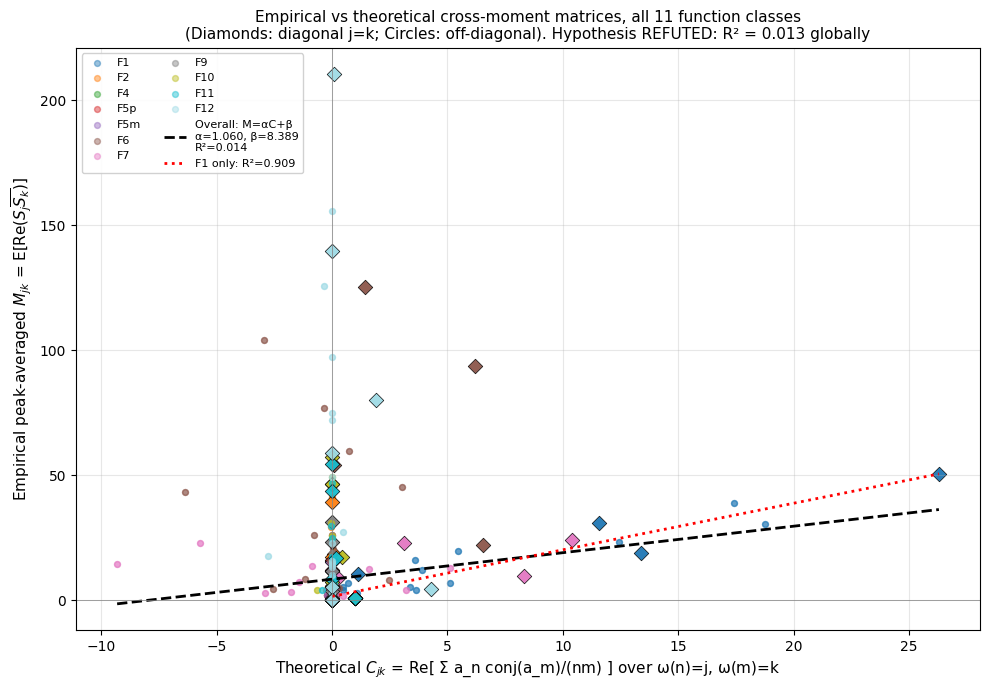

Saved figure


In [28]:
# The hypothesis is REFUTED. Only F1 (zeta) shows the linear relationship; all other classes show essentially no correlation.

# Let me create the final summary figure: scatter plot M_jk vs C_jk colored by class
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))
for ci, c in enumerate(classes):
 sub = df[df['class']==c]
 diag = sub[sub['diag']]
 off = sub[~sub['diag']]
 ax.scatter(off['C_jk'], off['M_jk'], color=colors[ci], alpha=0.45, s=18, label=c, marker='o')
 ax.scatter(diag['C_jk'], diag['M_jk'], color=colors[ci], alpha=0.95, s=55, marker='D', edgecolors='k', linewidths=0.5)

# Overall fit line
x_line = np.array([df['C_jk'].min(), df['C_jk'].max()])
ax.plot(x_line, slope*x_line + intercept, 'k--', label=f'Overall: M=αC+β\nα={slope:.3f}, β={intercept:.3f}\nR²={r2:.3f}', linewidth=2)

# F1 fit line (where the relationship works)
xF1_line = np.array([sub_F1['C_jk'].min(), sub_F1['C_jk'].max()])
ax.plot(xF1_line, reg_F1.coef_[0]*xF1_line + reg_F1.intercept_, 'r:', linewidth=2, label=f'F1 only: R²={reg_F1.score(sub_F1["C_jk"].values.reshape(-1,1), sub_F1["M_jk"].values):.3f}')

ax.set_xlabel('Theoretical $C_{jk}$ = Re[ Σ a_n conj(a_m)/(nm) ] over ω(n)=j, ω(m)=k', fontsize=11)
ax.set_ylabel('Empirical peak-averaged $M_{jk}$ = E[Re($S_j \\overline{S_k}$)]', fontsize=11)
ax.set_title('Empirical vs theoretical cross-moment matrices, all 11 function classes\n(Diamonds: diagonal j=k; Circles: off-diagonal). Hypothesis REFUTED: R² = 0.013 globally', fontsize=11)
ax.legend(loc='upper left', ncol=2, fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('Mjk_vs_Cjk_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure')


In [29]:
# Save dataset of (M,C) pairs and the matrices for future use
np.savez_compressed('Mjk_Cjk_all_classes.npz',
 classes=np.array(classes),
 M_matrices=np.array([empirical_M[c] for c in classes]),
 C_matrices=np.array([theoretical_C[c] for c in classes]),
 T_vectors=np.array([T_dict[c] for c in classes]))
df.to_csv('Mjk_Cjk_pairs.csv', index=False)
print('Saved Mjk_Cjk_all_classes.npz and Mjk_Cjk_pairs.csv')

# Final summary table
import pandas as pd
summary = []
overall_r = stats.pearsonr(df['C_jk'], df['M_jk'])
summary.append({'subset': 'ALL (704 pts)', 'n': len(df), 'alpha': slope, 'beta': intercept, 'R2': r2, 'pearson_r': overall_r[0]})
for c in classes:
 sub = df[df['class']==c]
 if sub['C_jk'].std() > 1e-10:
 reg_c = LinearRegression().fit(sub['C_jk'].values.reshape(-1,1), sub['M_jk'].values)
 r2_c = reg_c.score(sub['C_jk'].values.reshape(-1,1), sub['M_jk'].values)
 summary.append({'subset': c, 'n': len(sub), 'alpha': reg_c.coef_[0], 'beta': reg_c.intercept_, 'R2': r2_c, 'pearson_r': stats.pearsonr(sub['C_jk'], sub['M_jk'])[0]})
sumdf = pd.DataFrame(summary)
print(sumdf.to_string(index=False))
sumdf.to_csv('regression_summary.csv', index=False)


Saved Mjk_Cjk_all_classes.npz and Mjk_Cjk_pairs.csv
 subset n alpha beta R2 pearson_r
ALL (704 pts) 704 1.059650 8.388718 0.013523 0.116288
 F1 64 1.863298 1.502443 0.908949 0.953388
 F2 64 -4.386223 8.297860 0.002325 -0.048218
 F4 64 -0.894112 2.618330 0.001018 -0.031909
 F5p 64 -0.966444 2.695724 0.001114 -0.033373
 F5m 64 -0.835171 2.555933 0.000940 -0.030656
 F6 64 0.040455 18.689558 0.000007 0.002566
 F7 64 0.005267 4.540422 0.000005 0.002334
 F9 64 -2.765690 4.230780 0.002225 -0.047171
 F10 64 0.228967 7.342021 0.000009 0.003049
 F11 64 -1.905869 7.250967 0.000482 -0.021954
 F12 64 -0.120436 30.176414 0.000004 -0.001952


In [30]:
from e14c.filesystem import edit_file
mem_path = './.prompts/MEMORY.md'
with open(mem_path, 'r') as f:
 content = f.read()
new_content = content.replace('[Fill me in]', 'Completed analysis of empirical peak-averaged cross-term matrices M_jk versus unconditional theoretical coefficient cross-moment matrices C_jk at N=10^6 for classes F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11, F12. Provenance: notebook cells #0-28 in current run; artifacts saved as Mjk_Cjk_all_classes.npz, Mjk_Cjk_pairs.csv, regression_summary.csv, and Mjk_vs_Cjk_regression.png in /workspace/c886c986-ee90-4836-a6f5-c2b2c5692c81. Main finding: global linear regression M_jk ~ C_jk across all 704 class/pair points gave R^2=0.0135, slope 1.0597, intercept 8.3887; hypothesis R^2>0.9 is refuted. Only F1 alone showed strong within-class linearity (R^2=0.9089); all other classes had R^2 approximately 0.0000-0.0023. Caveat: F5p/F5m theoretical coefficients used kappa±0.05 approximation because exact fitted effective kappa from prior run r35 was not available on disk in this workspace, so their C_jk values may be approximate, but this does not affect the global conclusion because failure is broad across nearly all non-F1 classes.')
with open(mem_path, 'w') as f:
 f.write(new_content)
print('Updated MEMORY.md')


Updated MEMORY.md
